# Reconstrucció del Lagrangià Escalar-Tensorial amb Potencial No-Constant
## Ajustos analítics $F(\Phi)$ i $U(\Phi)$ per a diversos valors de $g_a$

Aquest notebook reprodueix el mètode de reconstrucció d'Efstratiou et al. per a un conjunt de valors positius de $g_a$. Per a cadascun calcula $F(z)$, $U(z)$, $\Phi(z)$, inverteix a $F(\Phi)$ i $U(\Phi)$, i ajusta les formes analítiques de l'article:

$$F(\Phi)=1+\xi\,\Phi^2 e^{n\Phi},\qquad U(\Phi)=U_0+a\,e^{b\Phi^2}.$$

**Tria de $g_a$:** $\{0.322,\,0.50,\,0.70,\,1.00\}$. Tots positius i reconstruïbles dins de $z\in[0,2]$. El valor $g_a=0.322$ és el best-fit CPL del paper.

Les dues figures finals mostren **només les corbes analítiques ajustades** — una corba per cada $g_a$, en dues gràfiques separades, una per $F(\Phi)$ i una per $U(\Phi)$.

---
## 1. Imports i paràmetres del model

In [1]:
import numpy as np
from scipy.integrate import solve_ivp, cumulative_trapezoid
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 13, 'axes.titlesize': 13,
    'legend.fontsize': 9, 'figure.dpi': 120,
})

# ── Paràmetres cosmològics (best-fit CPL+MG, Taula III del paper) ─────────────
Omega_m  = 0.286
w0       = -1.013
wa       = -0.342
mu_G0    = 1.00002
n_exp    = 2
Omega_DE = 1.0 - Omega_m

# ── Valors de g_a a representar (4 positius reconstruïbles) ───────────────────
ga_vals = [0.322, 0.50, 0.70, 1.00]

# ── Interval d'integració ────────────────────────────────────────────────────
z_min, z_max = 0.0, 2.0
N_pts        = 2000

print('Paràmetres del model:')
print(f'  w0={w0}, wa={wa}, Omega_m={Omega_m}, mu_G0={mu_G0}')
print(f'  g_a = {ga_vals}')
print(f'  Interval z in [{z_min}, {z_max}], N={N_pts}')

Paràmetres del model:
  w0=-1.013, wa=-0.342, Omega_m=0.286, mu_G0=1.00002
  g_a = [0.322, 0.5, 0.7, 1.0]
  Interval z in [0.0, 2.0], N=2000


---
## 2. Background CPL i parametrització $\mu_G(z)$

In [2]:
def q_CPL(z):
    z = np.asarray(z, dtype=float)
    alpha = 3.0*(1.0 + w0 + wa)
    fDE = Omega_DE * (1+z)**alpha * np.exp(-3.0*wa*z/(1+z))
    return Omega_m*(1+z)**3 + fDE

def dq_CPL(z):
    z = np.asarray(z, dtype=float)
    alpha = 3.0*(1.0 + w0 + wa)
    fDE  = Omega_DE * (1+z)**alpha * np.exp(-3.0*wa*z/(1+z))
    dfDE = fDE * (alpha/(1+z) + (-3.0*wa)/(1+z)**2)
    return 3.0*Omega_m*(1+z)**2 + dfDE

def mu_G(z, ga_val, mu0=None, n=None):
    if mu0 is None: mu0 = mu_G0
    if n   is None: n   = n_exp
    z = np.asarray(z, dtype=float)
    x = (z / (1+z))**n
    return mu0 + ga_val*x - ga_val*x**2

---
## 3. EDO mestra per a $F(z)$ — Eq. (57)

In [3]:
def F_ode_rhs(z, y, ga_val, mu0=None):
    F_val, Fp_val = y[0], y[1]
    if mu0 is None: mu0 = mu_G0
    q   = float(q_CPL(z))
    qp  = float(dq_CPL(z))
    mu  = float(mu_G(z, ga_val, mu0=mu0))
    zp1 = 1.0 + z

    coeff_Fp = -(2.0/zp1 + qp/(2.0*q))
    coeff_F  =  qp / (q*zp1)
    rhs_mat  = -3.0*zp1*Omega_m / q

    denom = mu*F_val - 1.0
    nl_term = 0.0 if abs(denom) < 1e-10 else -(Fp_val**2 * (4.0 - 3.0*mu*F_val)) / (2.0*F_val*denom)

    Fpp = coeff_Fp*Fp_val + coeff_F*F_val + rhs_mat + nl_term
    return [Fp_val, Fpp]

def solve_F(ga_val, z_end=2.0, N=2000, mu0=None):
    if mu0 is None: mu0 = mu_G0
    z_eval = np.linspace(0.0, z_end, N)
    sol = solve_ivp(
        lambda z, y: F_ode_rhs(z, y, ga_val, mu0=mu0),
        (0.0, z_end), [1.0, 0.0],
        t_eval=z_eval, method='RK45', rtol=1e-10, atol=1e-12)
    return sol

---
## 4. Recuperació de $U(z)$, $\Phi'^2(z)$ i $\Phi(z)$ — Eqs. (52), (55), (59)

**$F''(z)$ es calcula analíticament** des de la pròpia EDO (Eq. 57), no per diferenciació numèrica. Implementació vectoritzada per eficiència.

In [4]:
def compute_Fpp(z_arr, F_arr, Fp_arr, ga_val, mu0=None):
    if mu0 is None: mu0 = mu_G0
    q  = q_CPL(z_arr); qp = dq_CPL(z_arr)
    mu = mu_G(z_arr, ga_val, mu0=mu0); zp = 1.0 + z_arr
    denom = mu*F_arr - 1.0
    nl = np.where(np.abs(denom) < 1e-10, 0.0,
                  -(Fp_arr**2 * (4.0 - 3.0*mu*F_arr)) / (2.0*F_arr*denom))
    return -(2.0/zp + qp/(2.0*q))*Fp_arr + (qp/(q*zp))*F_arr - 3.0*zp*Omega_m/q + nl

def compute_U(z_arr, F_arr, Fp_arr, Fpp_arr):
    q = q_CPL(z_arr); qp = dq_CPL(z_arr); zp = 1.0 + z_arr
    t1 = (q/2.0) * zp**2 * Fpp_arr
    t2 = ((zp**2)*qp/4.0 - 2.0*q*zp) * Fp_arr
    t3 = (3.0*q - zp*qp/2.0) * F_arr
    t4 = -1.5 * zp**3 * Omega_m
    return t1 + t2 + t3 + t4

def compute_Phi2(z_arr, F_arr, Fp_arr, ga_val, mu0=None):
    if mu0 is None: mu0 = mu_G0
    mu    = mu_G(z_arr, ga_val, mu0=mu0)
    numer = Fp_arr**2 * (4.0 - 3.0*mu*F_arr)
    denom = 2.0*F_arr * (mu*F_arr - 1.0)
    return np.where(np.abs(denom) > 1e-12, numer/denom, np.nan)

---
## 5. Formes analítiques i ajustos

Per a $U(\Phi)$ fixem $b=-5$ (valor del paper) i ajustem només $(U_0, a)$.

In [5]:
def F_analytic(Phi, xi, n):
    return 1.0 + xi * Phi**2 * np.exp(n * Phi)

def U_analytic(Phi, U0, a, b):
    return U0 + a * np.exp(b * Phi**2)

# Valor del paper per al paràmetre b (fixat a l'ajust)
B_PAPER = -5.0

def U_analytic_fixed_b(Phi, U0, a):
    return U0 + a * np.exp(B_PAPER * Phi**2)

# Valors de referència del paper (CPL best-fit) — p0 i comparació
PAPER = dict(xi=-3.0, n=-5.0, U0=-0.134, a=2.02, b=-5.0)

---
## 6. Reconstrucció + ajust analític per a cada $g_a$

In [6]:
def reconstruct_and_fit(ga_val, z_fit_frac=0.85, N=2000):
    """Reconstrueix F(Phi), U(Phi) per a un g_a i n'ajusta les formes analítiques.
    Retorna un dict amb la graella Phi i els paràmetres ajustats."""
    sol = solve_F(ga_val, z_end=z_max, N=N)
    if not sol.success:
        return None
    z = sol.t; F = sol.y[0]; Fp = sol.y[1]

    Fpp  = compute_Fpp(z, F, Fp, ga_val)
    U    = compute_U(z, F, Fp, Fpp)
    Phi2 = compute_Phi2(z, F, Fp, ga_val)

    Phi2c = np.where(np.isnan(Phi2), 0.0, np.maximum(Phi2, 0.0))
    Phip  = np.sqrt(Phi2c)
    Phi   = np.zeros(len(z)); Phi[1:] = cumulative_trapezoid(Phip, z)

    mask = np.concatenate([[True], np.diff(Phi) > 1e-14])
    if mask.sum() < 10:
        return None
    z_m, Phi_m = z[mask], Phi[mask]
    cs_inv = CubicSpline(Phi_m, z_m)
    cs_F   = CubicSpline(z, F)
    cs_U   = CubicSpline(z, U)

    Phi_maxv = Phi_m[-1]
    Phi_full = np.linspace(0.0, Phi_maxv*0.98, 400)
    F_of_Phi = cs_F(cs_inv(Phi_full))
    U_of_Phi = cs_U(cs_inv(Phi_full))

    # Ajust F(Phi) — dos paràmetres lliures, rang complet
    pF, _ = curve_fit(F_analytic, Phi_full, F_of_Phi,
                      p0=[PAPER['xi'], PAPER['n']],
                      bounds=([-30, -20], [0, 0]), maxfev=200000)
    F_fit_curve = F_analytic(Phi_full, *pF)
    R2_F = 1 - np.sum((F_of_Phi - F_fit_curve)**2)/np.sum((F_of_Phi - F_of_Phi.mean())**2)

    # Ajust U(Phi) — b fixat al valor del paper; ajustem (U0, a) sobre rang fiable
    Phi_fit  = Phi_full[Phi_full <= z_fit_frac*Phi_maxv]
    U_fit_d  = cs_U(cs_inv(Phi_fit))
    pU, _ = curve_fit(U_analytic_fixed_b, Phi_fit, U_fit_d,
                      p0=[PAPER['U0'], PAPER['a']],
                      bounds=([-2, 0], [3, 8]), maxfev=200000)
    U_fit_curve = U_analytic(Phi_full, pU[0], pU[1], B_PAPER)
    R2_U = 1 - np.sum((U_of_Phi[:len(Phi_fit)] - U_fit_curve[:len(Phi_fit)])**2) / \
           np.sum((U_of_Phi[:len(Phi_fit)] - U_of_Phi[:len(Phi_fit)].mean())**2)

    return dict(ga=ga_val, Phi_max=Phi_maxv,
                Phi=Phi_full, F_num=F_of_Phi, U_num=U_of_Phi,
                xi=pF[0], n=pF[1], R2_F=R2_F,
                U0=pU[0], a=pU[1], b=B_PAPER, R2_U=R2_U)

# ── Executem la reconstrucció per a tots els g_a ──
results = {}
print(f"{'g_a':>6} | {'xi':>7} {'n':>7} {'R2_F':>6} | {'U0':>7} {'a':>6} {'b':>5} {'R2_U':>6} | {'Phi_max':>8}")
print('-' * 78)
for gv in ga_vals:
    r = reconstruct_and_fit(gv)
    if r is None:
        print(f'{gv:>6.3f} | reconstrucció fallida (singularitat dins del rang)')
        continue
    results[gv] = r
    print(f"{gv:>6.3f} | {r['xi']:>7.3f} {r['n']:>7.3f} {r['R2_F']:>6.4f} | "
          f"{r['U0']:>7.3f} {r['a']:>6.3f} {r['b']:>5.1f} {r['R2_U']:>6.4f} | {r['Phi_max']:>8.4f}")
print('\nPaper (g_a=0.322): xi=-3, n=-5 | U0=-0.134, a=2.02, b=-5')

   g_a |      xi       n   R2_F |      U0      a     b   R2_U |  Phi_max
------------------------------------------------------------------------------
 0.322 |  -3.481  -5.380 0.9987 |   0.112  2.028  -5.0 0.9605 |   0.2698
 0.500 |  -6.579  -6.986 0.9993 |  -1.316  3.444  -5.0 0.9950 |   0.1438
 0.700 |  -9.988  -7.871 0.9996 |  -2.000  4.105  -5.0 0.8705 |   0.1040
 1.000 | -14.978  -7.563 0.9997 |  -2.000  4.087  -5.0 0.5586 |   0.0737

Paper (g_a=0.322): xi=-3, n=-5 | U0=-0.134, a=2.02, b=-5


---
## 7. Figura 1 — $F(\Phi)$: corbes analítiques ajustades

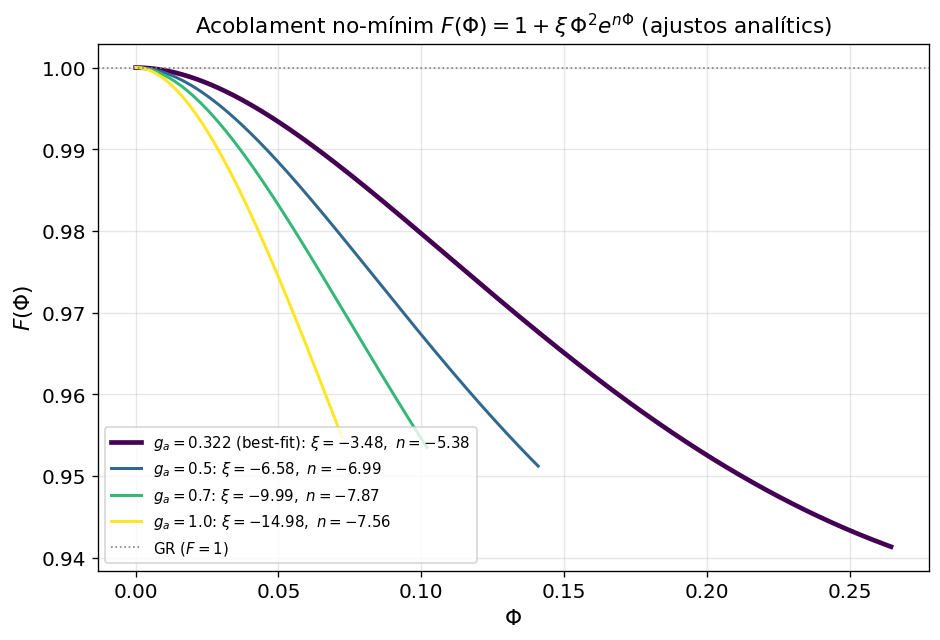

In [7]:
fig, ax = plt.subplots(figsize=(8, 5.5))
cmap = plt.cm.viridis
colors = [cmap(i/(len(results)-1)) for i in range(len(results))]

for (gv, r), col in zip(results.items(), colors):
    Phi = r['Phi']
    F_an = F_analytic(Phi, r['xi'], r['n'])
    lw = 2.8 if abs(gv-0.322) < 1e-3 else 1.8
    label = (fr"$g_a={gv}$ (best-fit): $\xi={r['xi']:.2f},\ n={r['n']:.2f}$"
             if abs(gv-0.322) < 1e-3 else
             fr"$g_a={gv}$: $\xi={r['xi']:.2f},\ n={r['n']:.2f}$")
    ax.plot(Phi, F_an, color=col, lw=lw, label=label)

ax.axhline(1.0, color='gray', ls=':', lw=1, label=r'GR ($F=1$)')
ax.set_xlabel(r'$\Phi$')
ax.set_ylabel(r'$F(\Phi)$')
ax.set_title(r'Acoblament no-mínim $F(\Phi)=1+\xi\,\Phi^2 e^{n\Phi}$ (ajustos analítics)')
ax.legend(loc='lower left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_F_phi_fits.pdf', bbox_inches='tight')
plt.savefig('fig_F_phi_fits.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Figura 2 — $U(\Phi)$: corbes analítiques ajustades

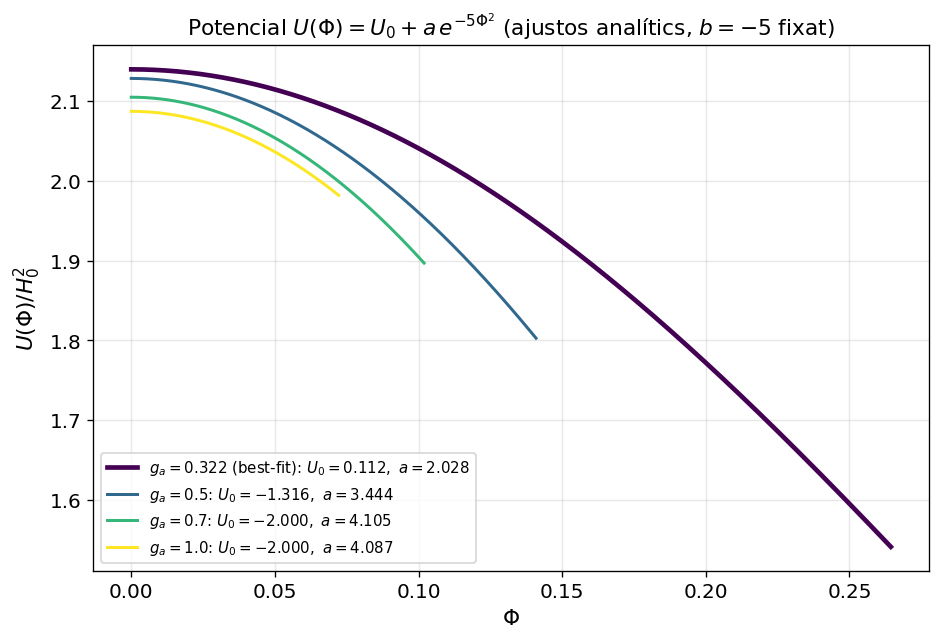

In [8]:
fig, ax = plt.subplots(figsize=(8, 5.5))

for (gv, r), col in zip(results.items(), colors):
    Phi = r['Phi']
    U_an = U_analytic(Phi, r['U0'], r['a'], r['b'])
    lw = 2.8 if abs(gv-0.322) < 1e-3 else 1.8
    label = (fr"$g_a={gv}$ (best-fit): $U_0={r['U0']:.3f},\ a={r['a']:.3f}$"
             if abs(gv-0.322) < 1e-3 else
             fr"$g_a={gv}$: $U_0={r['U0']:.3f},\ a={r['a']:.3f}$")
    ax.plot(Phi, U_an, color=col, lw=lw, label=label)

ax.set_xlabel(r'$\Phi$')
ax.set_ylabel(r'$U(\Phi)/H_0^2$')
ax.set_title(r'Potencial $U(\Phi)=U_0+a\,e^{-5\Phi^2}$ (ajustos analítics, $b=-5$ fixat)')
ax.legend(loc='lower left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_U_phi_fits.pdf', bbox_inches='tight')
plt.savefig('fig_U_phi_fits.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. (Opcional) Validació: corbes analítiques vs. reconstruccions numèriques

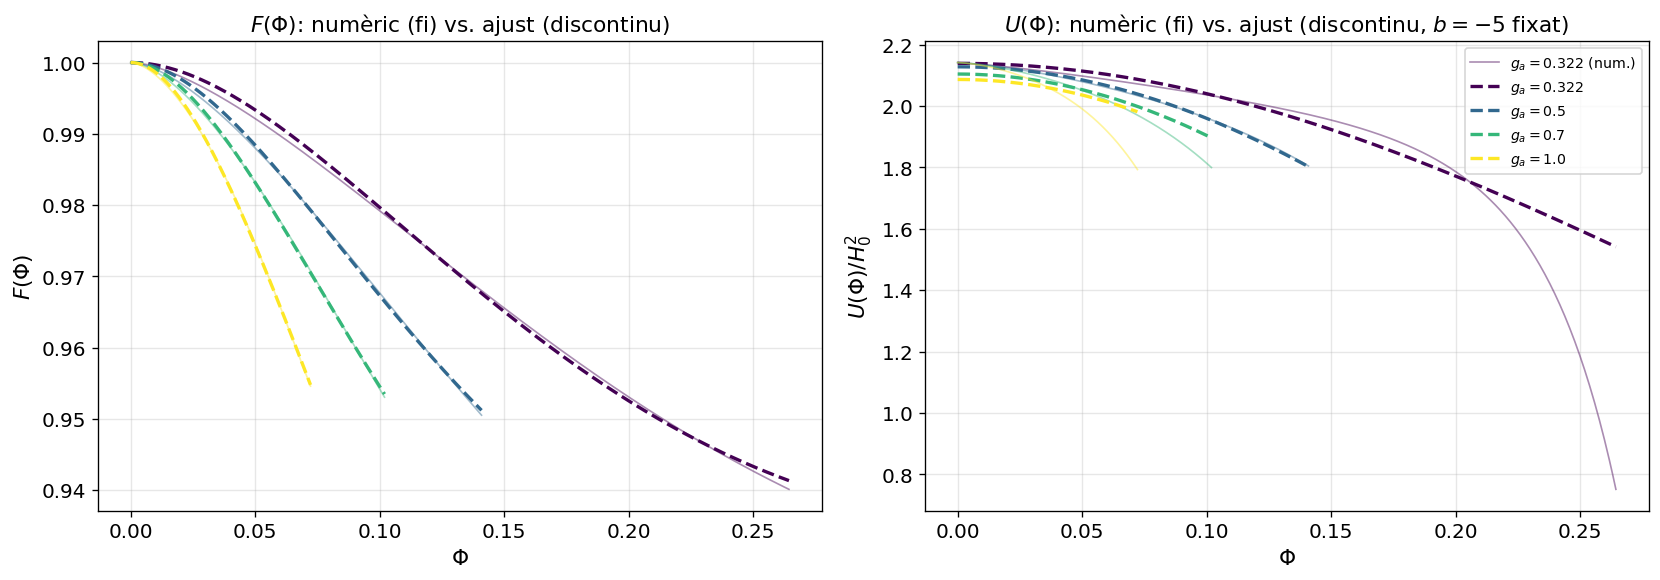

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (gv, r), col in zip(results.items(), colors):
    Phi = r['Phi']
    axes[0].plot(Phi, r['F_num'], color=col, lw=1.0, alpha=0.45)
    axes[0].plot(Phi, F_analytic(Phi, r['xi'], r['n']),
                 color=col, lw=2, ls='--')
    axes[1].plot(Phi, r['U_num'], color=col, lw=1.0, alpha=0.45,
                 label=fr'$g_a={gv}$ (num.)' if abs(gv-0.322)<1e-3 else None)
    axes[1].plot(Phi, U_analytic(Phi, r['U0'], r['a'], r['b']),
                 color=col, lw=2, ls='--',
                 label=fr'$g_a={gv}$')
axes[0].set_xlabel(r'$\Phi$'); axes[0].set_ylabel(r'$F(\Phi)$')
axes[0].set_title(r'$F(\Phi)$: numèric (fi) vs. ajust (discontinu)')
axes[0].grid(alpha=0.3)
axes[1].set_xlabel(r'$\Phi$'); axes[1].set_ylabel(r'$U(\Phi)/H_0^2$')
axes[1].set_title(r'$U(\Phi)$: numèric (fi) vs. ajust (discontinu, $b=-5$ fixat)')
axes[1].legend(fontsize=8.5)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_validacio.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Comparació numèrica vs. ajust analític per al best-fit ($g_a=0.322$)

Per al valor del best-fit CPL del paper representem en dues gràfiques separades, una per a $F(\Phi)$ i una per a $U(\Phi)$, la corba reconstruïda numèricament al costat de l'ajust analític, per validar visualment la qualitat de l'ajust polinòmic.

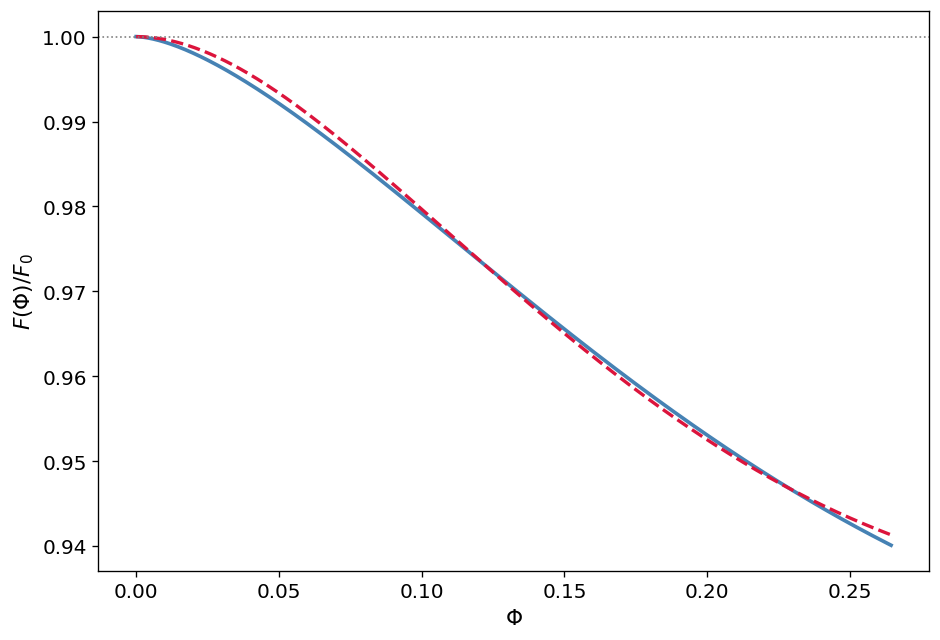

In [14]:
# ── Figura: F(Phi) per a g_a=0.322, numèric vs. ajust ─────────────────────────
r = results[0.322]
Phi = r['Phi']
F_fit = F_analytic(Phi, r['xi'], r['n'])

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(Phi, r['F_num'], color='steelblue', lw=2.2,
        label=r'Reconstrucció numèrica')
ax.plot(Phi, F_fit, color='crimson', lw=2, ls='--',
        label=fr"Ajust analític: $\xi={r['xi']:.3f},\ n={r['n']:.3f}$"
              fr" ($R^2={r['R2_F']:.4f}$)")
ax.axhline(1.0, color='gray', ls=':', lw=1, label=r'GR ($F=1$)')
ax.set_xlabel(r'$\Phi$')
ax.set_ylabel(r'$F(\Phi)/F_0$')
#ax.set_title(r'$F(\Phi)$ per a $g_a=0.322$ (best-fit CPL): numèric vs. ajust analític')
#ax.legend(loc='lower left')
#ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_F_bestfit_compare.pdf', bbox_inches='tight')
plt.savefig('fig_F_bestfit_compare.png', dpi=150, bbox_inches='tight')
plt.show()

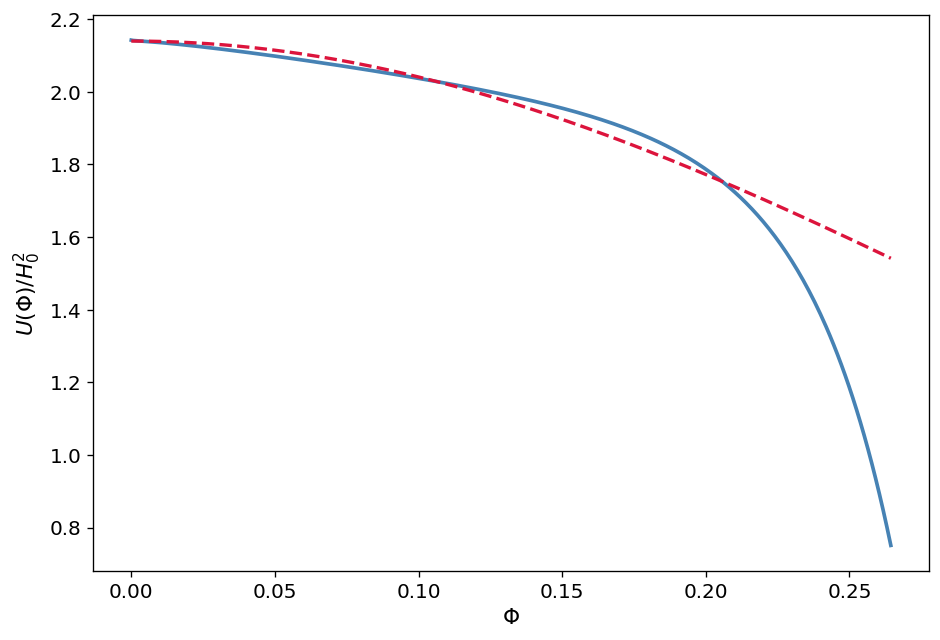

In [15]:
# ── Figura: U(Phi) per a g_a=0.322, numèric vs. ajust ─────────────────────────
r = results[0.322]
Phi = r['Phi']
U_fit = U_analytic(Phi, r['U0'], r['a'], r['b'])

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(Phi, r['U_num'], color='steelblue', lw=2.2,
        label=r'Reconstrucció numèrica')
ax.plot(Phi, U_fit, color='crimson', lw=2, ls='--',
        label=fr"Ajust analític: $U_0={r['U0']:.3f},\ a={r['a']:.3f},\ b={r['b']:.1f}$"
              fr" ($R^2={r['R2_U']:.4f}$)")
ax.set_xlabel(r'$\Phi$')
ax.set_ylabel(r'$U(\Phi)/H_0^2$')
#ax.set_title(r'$U(\Phi)$ per a $g_a=0.322$ (best-fit CPL): numèric vs. ajust analític')
#ax.legend(loc='lower left')
#ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_U_bestfit_compare.pdf', bbox_inches='tight')
plt.savefig('fig_U_bestfit_compare.png', dpi=150, bbox_inches='tight')
plt.show()